3_NHANES - Módulo de Balance (Examination Data)

¿Quién lo creó y cómo se obtuvieron los datos?
El dataset fue recolectado por el National Center for Health Statistics (NCHS), perteneciente a los Centros para el Control y la Prevención de Enfermedades (CDC) del gobierno de los Estados Unidos. Los datos se obtienen mediante un diseño muestral complejo, multietápico y probabilístico que garantiza representatividad nacional de la población civil no institucionalizada de los EE.UU.
El módulo de Balance forma parte del componente de Examination Data, lo que significa que los datos no se recolectaron por encuesta, sino mediante pruebas físicas estandarizadas realizadas en el Centro de Examen Móvil (Mobile Examination Center, MEC), que es una unidad móvil equipada que el CDC desplaza a distintos puntos del país. Técnicos certificados aplicaron protocolos estrictos de medición del equilibrio físico a los participantes seleccionados.

¿De qué trata?
Este módulo mide la capacidad de equilibrio y estabilidad postural de los participantes. El equilibrio es una función neurológica y musculoesquelética crítica: su deterioro está asociado con caídas, lesiones, envejecimiento, enfermedades neurológicas (como Parkinson o esclerosis múltiple), diabetes con neuropatía periférica, y problemas del oído interno.
El test utilizado es una versión simplificada del Balance Error Scoring System (BESS) o pruebas similares de equilibrio en distintas condiciones de superficie y posición visual, evaluando cuánto tiempo puede una persona mantenerse estable bajo distintas condiciones de dificultad creciente.


¿Qué contiene?
Tu archivo tiene 4.771 participantes y 45 variables, todas codificadas con prefijos BAX (mediciones físicas) y BAQ (preguntas del cuestionario asociado). Las variables más relevantes son: SEQN -> Identificador único del participante (clave de unión con otros módulos); BAXMSTAT -> Estado general de la prueba de balance (si fue completada o no); BAQ110–BAQ173 -> Preguntas sobre historial de problemas de equilibrio, caídas, mareos y uso de ayudas para caminar; BAXPF11/12... -> Puntuación de la prueba en cada posición (intento 1 e intento 2); BAXTC11/12... -> Tiempo completado en cada prueba (en segundos); BAARFC11/12... -> Razón por la que el participante falló o no completó la prueba.
Las pruebas se repiten en 5 condiciones distintas (numeradas del 1 al 5), cada una con 2 intentos, combinando: posición de los pies (paralelos, semitándem, tándem) y tipo de superficie (firme o de espuma), con los ojos abiertos o cerrados. Eso explica la gran cantidad de columnas con patrones repetidos.
Los valores nulos son abundantes (algunas columnas superan el 95% de NaN) porque no todos los participantes completaron todas las posiciones, ya sea por limitaciones físicas, edad, o criterios de exclusión del protocolo.


¿Cuál será el objetivo del modelo?
El objetivo es un problema de clasificación binaria o regresión, dependiendo del enfoque elegido:
Predecir si un participante completa exitosamente las pruebas de equilibrio más difíciles (posición tándem con ojos cerrados sobre superficie de espuma) en función de sus respuestas sobre historial de caídas, mareos, uso de bastón, y resultados en las pruebas más simples.

In [1]:
# ============================================================
# LIBRERÍAS GENERALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [2]:
# ── PASO 1: CARGA — archivo .xpt (formato SAS del CDC) ──────
df_nhanes = pd.read_sas('Datasets/3_NHANES.xpt', format='xport')

print('Filas y columnas:', df_nhanes.shape)
print('\nColumnas:', list(df_nhanes.columns))

Filas y columnas: (4771, 45)

Columnas: ['SEQN', 'BAXMSTAT', 'BAXRXNC', 'BAXRXND', 'BAX5STAT', 'BAQ110', 'BAQ121', 'BAQ125', 'BAQ132', 'BAQ140', 'BAQ150', 'BAQ160', 'BAQ170', 'BAQ201', 'BAQ173', 'BAXPF11', 'BAXTC11', 'BAARFC11', 'BAXPF12', 'BAXTC12', 'BAARFC12', 'BAXPF21', 'BAXTC21', 'BAARFC21', 'BAXPF22', 'BAXTC22', 'BAARFC22', 'BAXPF31', 'BAXTC31', 'BAARFC31', 'BAXPF32', 'BAXTC32', 'BAARFC32', 'BAXPF41', 'BAXTC41', 'BAARFC41', 'BAXPF42', 'BAXTC42', 'BAARFC42', 'BAXPF51', 'BAXTC51', 'BAARFC51', 'BAXPF52', 'BAXTC52', 'BAARFC52']


Porcentaje de nulos por columna:
BAARFC12    99.9
BAARFC32    99.6
BAARFC22    99.5
BAXTC12     99.0
BAXPF12     99.0
BAARFC11    99.0
BAXPF32     98.3
BAXTC32     98.3
BAARFC31    98.3
BAXTC22     98.0
BAXPF22     98.0
BAARFC21    98.0
BAXRXNC     95.7
BAXRXND     95.5
BAARFC42    85.2
BAARFC52    83.4
BAXTC52     74.4
BAXPF52     73.8
BAARFC51    73.0
BAXTC42     72.4
BAXPF42     70.9
BAARFC41    70.9
BAXTC51     45.6
BAXPF51     44.8
BAQ201      31.1
BAQ170      26.3
BAQ160      24.2
BAXTC41     19.3
BAXPF41     19.0
BAXTC31     18.6
BAXPF31     18.3
BAXTC21     17.4
BAXPF21     17.4
BAXTC11     17.2
BAXPF11     17.2
BAQ173      16.8
BAQ150      16.7
BAQ140      15.7
BAQ132      15.7
BAQ125      10.3
BAQ121       9.8
BAQ110       8.6
BAX5STAT     4.3
BAXMSTAT     0.0
SEQN         0.0
dtype: float64


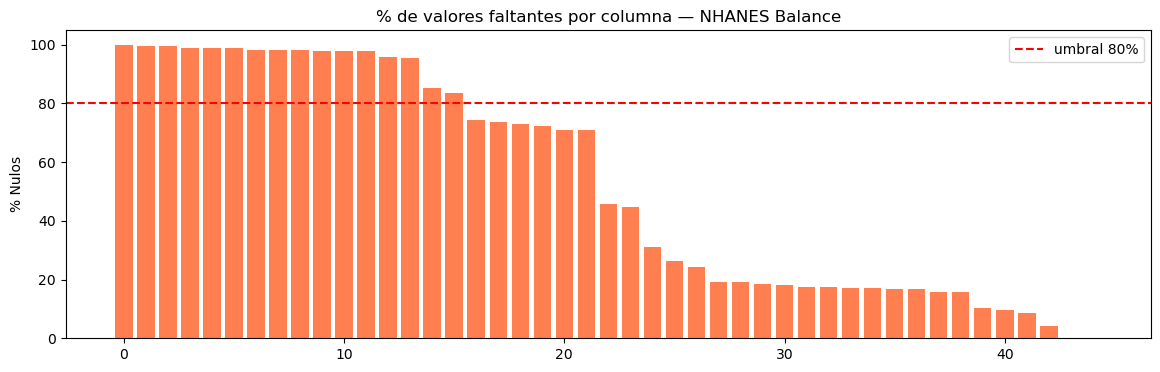

In [3]:
# ── PASO 2: DESCRIPCIÓN DE NULOS ────────────────────────────
pct_nulos = (df_nhanes.isnull().mean() * 100).round(1)
print('Porcentaje de nulos por columna:')
print(pct_nulos.sort_values(ascending=False))

plt.figure(figsize=(14, 4))
plt.bar(range(len(pct_nulos)), pct_nulos.sort_values(ascending=False).values, color='coral')
plt.axhline(y=80, color='red', linestyle='--', label='umbral 80%')
plt.title('% de valores faltantes por columna — NHANES Balance')
plt.ylabel('% Nulos')
plt.legend()
plt.show()

In [4]:
# ── PASO 3: LIMPIEZA ────────────────────────────────────────
# Eliminar columnas con más del 80% de nulos
# (muy pocas personas hicieron esas pruebas, no sirven para entrenar)
umbral = 0.80
cols_eliminar = [c for c in df_nhanes.columns
                 if df_nhanes[c].isnull().mean() > umbral]
print('Columnas eliminadas (>80% nulos):', cols_eliminar)

df_nh = df_nhanes.drop(columns=cols_eliminar)
print('Columnas restantes:', df_nh.shape[1])

# Imputar las columnas restantes con la mediana
for col in df_nh.columns:
    if df_nh[col].isnull().sum() > 0:
        df_nh[col] = df_nh[col].fillna(df_nh[col].median())

print('Nulos restantes:', df_nh.isnull().sum().sum())

Columnas eliminadas (>80% nulos): ['BAXRXNC', 'BAXRXND', 'BAARFC11', 'BAXPF12', 'BAXTC12', 'BAARFC12', 'BAARFC21', 'BAXPF22', 'BAXTC22', 'BAARFC22', 'BAARFC31', 'BAXPF32', 'BAXTC32', 'BAARFC32', 'BAARFC42', 'BAARFC52']
Columnas restantes: 29
Nulos restantes: 0


In [5]:
# ── PASO 4: CONSTRUIR X e y ─────────────────────────────────
# y = 1 si completó la prueba (BAXMSTAT==1), 0 si no
y_nhanes = (df_nh['BAXMSTAT'] == 1).values.astype(float)

# X = todo excepto el identificador y el target
X_raw_nh = df_nh.drop(columns=['SEQN', 'BAXMSTAT']).values.astype(float)
m_nh = y_nhanes.size

print('X shape:', X_raw_nh.shape)
print('y shape:', y_nhanes.shape)
print('Completaron prueba:', int(y_nhanes.sum()), 
      '| No completaron:', int((y_nhanes==0).sum()))

X shape: (4771, 27)
y shape: (4771,)
Completaron prueba: 3732 | No completaron: 1039


In [6]:
# ============================================================
# FUNCIÓN DE BALANCEO — oversampling con numpy
# ============================================================
def balancear(X, y):
    """
    Balancea un dataset desbalanceado usando OVERSAMPLING.
    
    ¿Qué hace?
    - Identifica cuántos ejemplos tiene cada clase
    - La clase con MÁS ejemplos queda igual
    - Las clases con MENOS ejemplos se repiten (con reemplazo)
      hasta tener la misma cantidad que la clase mayoritaria
    - Al final todas las clases tienen el mismo número de filas
    
    ¿Por qué oversampling y no undersampling?
    - Undersampling borra filas → perdemos información
    - Oversampling agrega filas → mantenemos toda la información original
    """
    clases = np.unique(y)
    n_max  = max(np.sum(y == c) for c in clases)   # tamaño de la clase más grande
    
    X_bal_list = []
    y_bal_list = []
    
    for c in clases:
        idx    = np.where(y == c)[0]               # índices de esta clase
        n_c    = len(idx)                           # cuántos ejemplos tiene
        
        if n_c < n_max:
            # repetir filas hasta alcanzar n_max
            extra  = n_max - n_c
            idx_extra = np.random.choice(idx, size=extra, replace=True)
            idx_final = np.concatenate([idx, idx_extra])
        else:
            idx_final = idx
        
        X_bal_list.append(X[idx_final])
        y_bal_list.append(y[idx_final])
    
    X_bal = np.concatenate(X_bal_list, axis=0)
    y_bal = np.concatenate(y_bal_list, axis=0)
    
    # Mezclar aleatoriamente para no dejar todas las clases juntas
    perm  = np.random.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]

def mostrar_balance(y, nombre, antes_despues='ANTES'):
    """Imprime cuántos ejemplos tiene cada clase."""
    clases, cuentas = np.unique(y, return_counts=True)
    print(f'  Balance {antes_despues} — {nombre}:')
    for c, n in zip(clases, cuentas):
        print(f'    Clase {int(c)}: {n} ({n/len(y)*100:.1f}%)')

np.random.seed(42)   # para reproducibilidad
print('Funciones de balanceo definidas')

Funciones de balanceo definidas


In [7]:
# ── BALANCEO — CAMBIO NUEVO ─────────────────────────────────
mostrar_balance(y_nhanes, 'NHANES', 'ANTES')

  Balance ANTES — NHANES:
    Clase 0: 1039 (21.8%)
    Clase 1: 3732 (78.2%)


In [8]:
def featureNormalize(X):
    """
    Normaliza las features de X.
    Para cada columna: resta la media y divide por la desviación estándar.
    
    Retorna:
      X_norm : X normalizado (mismo tamaño que X)
      mu     : media de cada columna (se guarda para normalizar datos nuevos)
      sigma  : desviación estándar de cada columna
    """
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)   # media de cada columna
    sigma  = np.std(X, axis=0)    # desviación estándar de cada columna
    X_norm = (X - mu) / sigma     # estandarización Z-score
    return X_norm, mu, sigma

In [11]:
# ── PASO 5: NORMALIZAR y COLUMNA DE UNOS ────────────────────
X_norm_nh, mu_nh, sigma_nh = featureNormalize(X_raw_nh)
X_bal_nh, y_bal_nh = balancear(X_norm_nh, y_nhanes)

mostrar_balance(y_bal_nh, 'NHANES', 'DESPUÉS')

m_nh = len(y_bal_nh)
X_nhanes = np.concatenate([np.ones((m_nh, 1)), X_bal_nh], axis=1)
y_nhanes  = y_bal_nh


print(f'\nX_nhanes: {X_nhanes.shape} | y_nhanes: {y_nhanes.shape}')

  Balance DESPUÉS — NHANES:
    Clase 0: 3732 (50.0%)
    Clase 1: 3732 (50.0%)

X_nhanes: (7464, 28) | y_nhanes: (7464,)
